# Clashfinder – demonstration using R1107TS128_4

The structure `R1107TS128_4.pdb` contains atoms with different occupancy
values, which can influence clash detection results.

In this notebook, clashfinder is executed in two modes:

1. with `--ignore-occupancy`
2. with `--ignore-occupancy` and additionally enabled
   `--enable-molprobity-mode`

The goal is to compare the number and characteristics of detected clashes
between these two modes.


### Run with `--ignore-occupancy` option


In [5]:
!python ../src/rnapolis/clashfinder.py \
  --ignore-occupancy \
  ./data/pdb/R1107TS128_4.pdb \
  > ./outputs/R1107TS128_4_ignore_occupancy.txt

In [6]:
!head ./outputs/R1107TS128_4_ignore_occupancy.txt

Clashes found in chain 0 with maximum occupancy sum equal to 2.0
    Clashes found between residues 0.A61 and 0.A62 with maximum occupancy sum equal to 2.0
        Clashes found between atoms O3' and P with occupancy sum of 2.0
    Clashes found in residue 0.C7 with maximum occupancy sum equal to 2.0
        Clashes found between atoms P and OP2 with occupancy sum of 2.0
    Clashes found in residue 0.A15 with maximum occupancy sum equal to 2.0
        Clashes found between atoms P and OP2 with occupancy sum of 2.0
    Clashes found between residues 0.U66 and 0.G67 with maximum occupancy sum equal to 2.0
        Clashes found between atoms O3' and P with occupancy sum of 2.0
    Clashes found between residues 0.G55 and 0.C56 with maximum occupancy sum equal to 2.0


- **48** clashes found


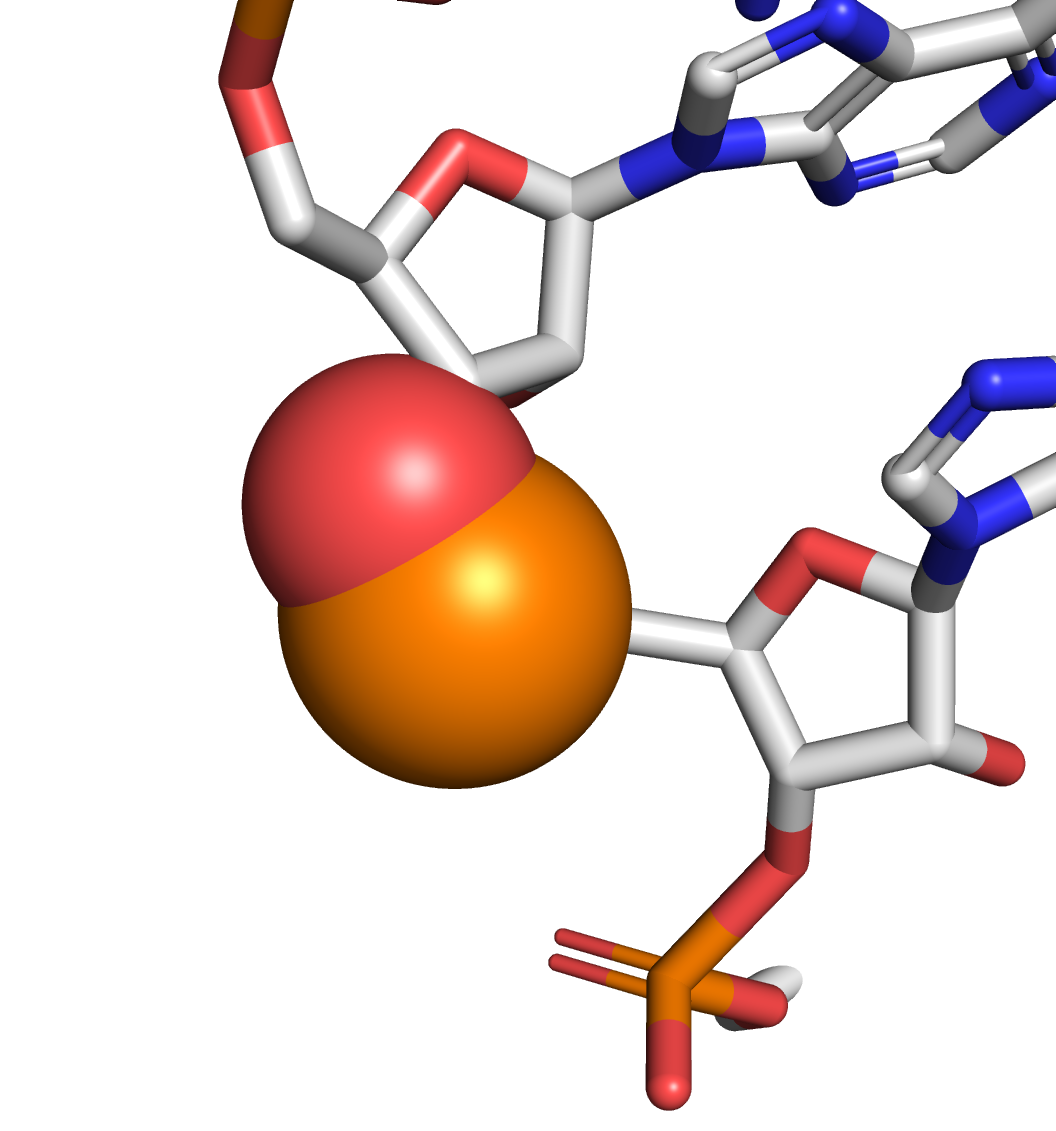


### Run with `--ignore-occupancy` and `--enable-molprobity-mode` options


In [7]:
!python ../src/rnapolis/clashfinder.py \
  --ignore-occupancy \
  --enable-molprobity-mode \
  ./data/pdb/R1107TS128_4.pdb \
  > ./outputs/R1107TS128_4_ignore_occupancy_molprobity.txt

In [8]:
!head ./outputs/R1107TS128_4_ignore_occupancy_molprobity.txt

Clashes found in chain 0 with maximum occupancy sum equal to 2.0
    Clashes found in residue 0.A40 with maximum occupancy sum equal to 2.0
        Clashes found between atoms C1' and N9 with occupancy sum of 2.0
        Clashes found between atoms C2 and N3 with occupancy sum of 2.0
        Clashes found between atoms C2' and C1' with occupancy sum of 2.0
        Clashes found between atoms C2' and O2' with occupancy sum of 2.0
        Clashes found between atoms C3' and C2' with occupancy sum of 2.0
        Clashes found between atoms C3' and O3' with occupancy sum of 2.0
        Clashes found between atoms C4' and C3' with occupancy sum of 2.0
        Clashes found between atoms C4' and O4' with occupancy sum of 2.0


- **1767** clashes found


In the standard run, clashfinder detected **48** clashes, which means that only the most obvious and strongest steric overlaps were reported. The program checks pairs of nearby atoms and marks a clash only when the distance between them is smaller than the sum of their van der Waals radii. This gives a simple overview of major geometric problems in the structure.

After enabling `--enable-molprobity-mode`, the number of detected clashes increased to **1767**. This happens because an extra margin of 0.5 Å is added to the distance cutoff, so even weaker and borderline overlaps are counted as clashes. In this mode clashfinder becomes much more sensitive and starts to report many small geometric inconsistencies that are ignored in the standard run. Since `--ignore-occupancy` is used in both cases, all clashes are reported only based on geometry, without considering atom occupancy values.
